# Lab 05: HOG-Based Industrial Defect Detection and Classification



## 0. Setup

In [ ]:
!pip install -q kagglehub opencv-python-headless scikit-image scikit-learn matplotlib pandas numpy

## 1. Download the dataset

`kagglehub` needs Kaggle credentials: either put `kaggle.json` in `~/.kaggle/` or set `KAGGLE_USERNAME` and `KAGGLE_KEY` as environment variables.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Path to dataset files: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split


## 2. Inspect the folder structure
Check whether the data uses class folders, XML (Pascal VOC) annotations, or both. The loader below handles both.

In [5]:
import os
DATA_ROOT="/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split"
for root, dirs, files in os.walk(DATA_ROOT):
    depth = root[len(DATA_ROOT):].count(os.sep)
    if depth <= 3:
        print('  ' * depth + os.path.basename(root) + '/', len(files), 'files')

neu-steel-surface-defect-detect-trainvalid-split/ 0 files
  valid_images/ 100 files
  valid_annotations/ 100 files
  train_images/ 1700 files
  train_annotations/ 1700 files


## 3. Imports and configuration

In [6]:
import glob
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

# 128x128 keeps the 4x4 cell HOG feature vectors manageable in RAM (200x200 works but is heavy)
IMG_SIZE = (128, 128)
EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

def norm(s):
    return s.strip().lower().replace(' ', '_').replace('-', '_')

DEFECT_CLASSES = [norm(c) for c in ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']]
ALLOWED = set(DEFECT_CLASSES + ['normal'])  # 'normal' only if you add defect-free images
print('Classes:', DEFECT_CLASSES)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']


## 4. Load the dataset (Tasks 1–2)

Each image gets a label from (a) its VOC XML annotation, using the most frequent defect name in the file, or (b) its parent folder name if there is no XML.

In [7]:
def xml_labels(xml_path):
    root = ET.parse(xml_path).getroot()
    return [norm(o.findtext('name')) for o in root.findall('object') if o.findtext('name')]

# Map image stem -> dominant defect name from XML files
xml_map = {}
for xp in glob.glob(os.path.join(DATA_ROOT, '**', '*.xml'), recursive=True):
    names = xml_labels(xp)
    if names:
        stem = os.path.splitext(os.path.basename(xp))[0]
        xml_map[stem] = Counter(names).most_common(1)[0][0]

rows = []
for p in glob.glob(os.path.join(DATA_ROOT, '**', '*'), recursive=True):
    if p.lower().endswith(EXTS):
        stem = os.path.splitext(os.path.basename(p))[0]
        label = xml_map.get(stem) or norm(os.path.basename(os.path.dirname(p)))
        rows.append((p, label))

df = pd.DataFrame(rows, columns=['path', 'label'])
print('Total images found:', len(df))
print('Labels seen (before filtering):', df.label.value_counts().to_dict())

df = df[df.label.isin(ALLOWED)].reset_index(drop=True)
print('Usable images:', len(df))
df.head()

Total images found: 1800
Labels seen (before filtering): {'inclusion': 312, 'patches': 307, 'rolled_in_scale': 300, 'crazing': 300, 'scratches': 291, 'pitted_surface': 290}
Usable images: 1800


,path,label
0,/kaggle/input/neu-steel-surface-defect-detect-...,pitted_surface
1,/kaggle/input/neu-steel-surface-defect-detect-...,crazing
2,/kaggle/input/neu-steel-surface-defect-detect-...,scratches
3,/kaggle/input/neu-steel-surface-defect-detect-...,crazing
4,/kaggle/input/neu-steel-surface-defect-detect-...,rolled_in_scale


## 5. Dataset inspection (Task 1)

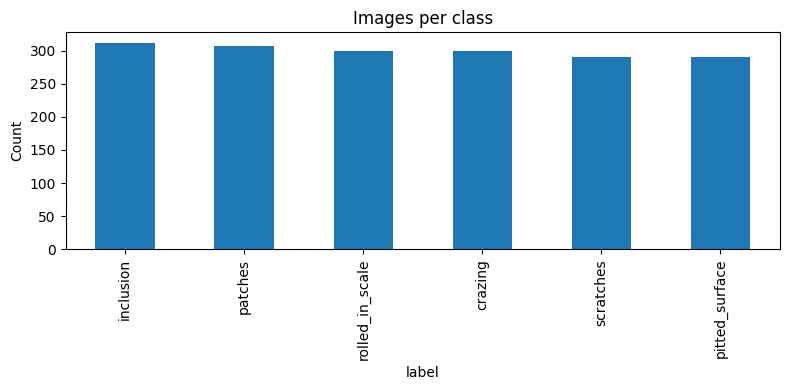

Original image sizes (first 100): [((200, 200), 100)]


In [8]:
counts = df.label.value_counts()
counts.plot(kind='bar', figsize=(8, 4), title='Images per class')
plt.ylabel('Count'); plt.tight_layout(); plt.show()

sizes = Counter(cv2.imread(p, cv2.IMREAD_UNCHANGED).shape[:2] for p in df.path[:100])
print('Original image sizes (first 100):', sizes.most_common(5))

## 6. Preprocessing (Tasks 2–3)
Grayscale, resize to a common size, and histogram equalisation to reduce lighting variation.

In [9]:
def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return cv2.equalizeHist(img)

def hog_feat(img, cell=8, orient=9, vis=False):
    return hog(img, orientations=orient, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm='L2-Hys',
               visualize=vis, feature_vector=True)

## 7. HOG visualisation (Task 5)

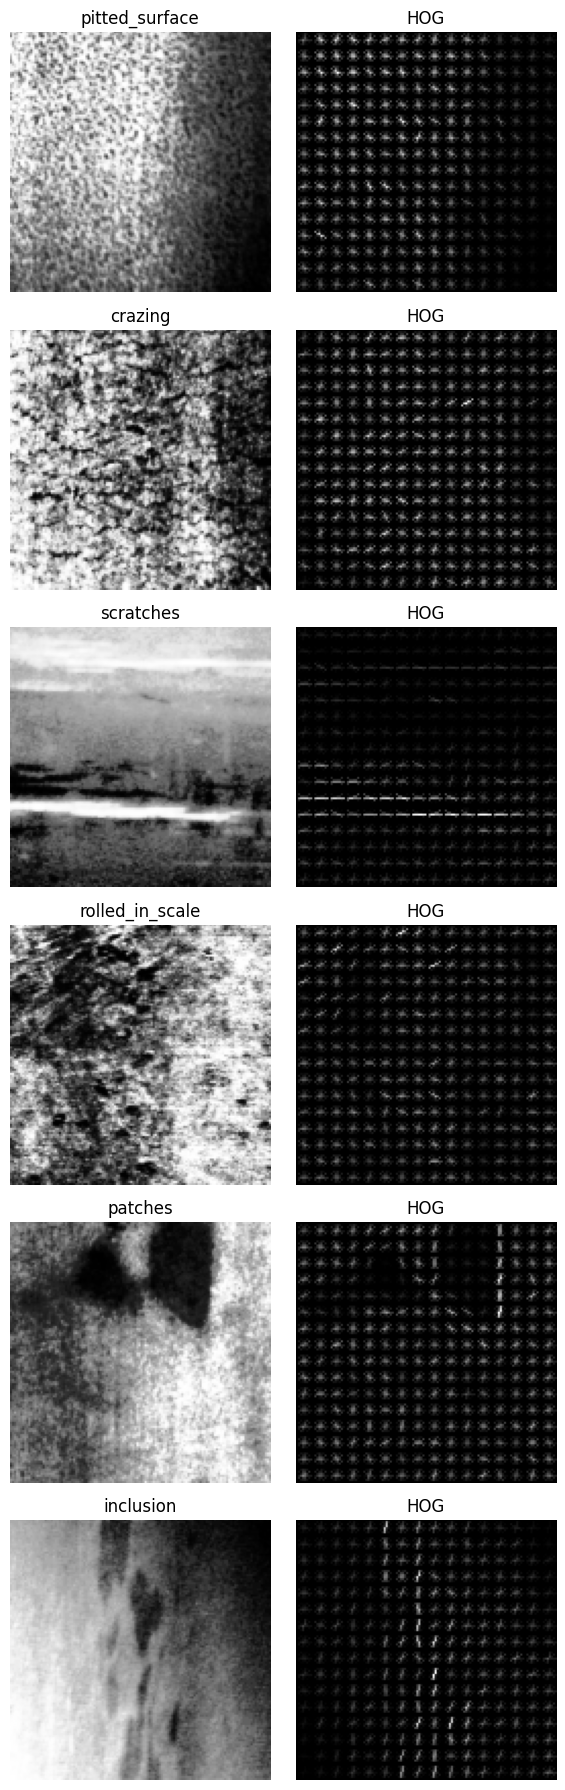

In [10]:
samples = df.groupby('label').head(1).reset_index(drop=True)
fig, axes = plt.subplots(len(samples), 2, figsize=(6, 3 * len(samples)))
for i, (p, l) in enumerate(zip(samples.path, samples.label)):
    img = preprocess(p)
    _, hog_img = hog_feat(img, 8, 9, vis=True)
    axes[i, 0].imshow(img, cmap='gray'); axes[i, 0].set_title(l); axes[i, 0].axis('off')
    axes[i, 1].imshow(hog_img, cmap='gray'); axes[i, 1].set_title('HOG'); axes[i, 1].axis('off')
plt.tight_layout(); plt.show()

## 8. Parameter sweep: HOG cell size × orientations × classifier (Tasks 4, 6–8, 11)

In [11]:
images = np.array([preprocess(p) for p in df.path])
y = df.label.values

def features(cell, orient):
    return np.array([hog_feat(im, cell, orient) for im in images], dtype=np.float32)

def make_models():
    return {
        'HOG + SVM': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=0)),
        'HOG + RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0),
    }

def metrics(yt, yp):
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(yt, yp), 'precision': p, 'recall': r, 'f1': f1}

idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.25, stratify=y, random_state=0)

results = []
for cell in [4, 8, 16]:
    for orient in [6, 9, 12]:
        X = features(cell, orient)
        for name, clf in make_models().items():
            clf.fit(X[idx_tr], y[idx_tr])
            m = metrics(y[idx_te], clf.predict(X[idx_te]))
            results.append({'cell': cell, 'orient': orient, 'model': name, **m})
            print(f'cell={cell:2d} orient={orient:2d} {name:20s} acc={m["accuracy"]:.3f} f1={m["f1"]:.3f}')

res_df = pd.DataFrame(results).round(3)
res_df

cell= 4 orient= 6 HOG + SVM            acc=0.789 f1=0.781
cell= 4 orient= 6 HOG + RandomForest   acc=0.600 f1=0.562
cell= 4 orient= 9 HOG + SVM            acc=0.764 f1=0.751
cell= 4 orient= 9 HOG + RandomForest   acc=0.587 f1=0.547
cell= 4 orient=12 HOG + SVM            acc=0.787 f1=0.774
cell= 4 orient=12 HOG + RandomForest   acc=0.600 f1=0.562
cell= 8 orient= 6 HOG + SVM            acc=0.871 f1=0.870
cell= 8 orient= 6 HOG + RandomForest   acc=0.720 f1=0.698
cell= 8 orient= 9 HOG + SVM            acc=0.840 f1=0.837
cell= 8 orient= 9 HOG + RandomForest   acc=0.740 f1=0.717
cell= 8 orient=12 HOG + SVM            acc=0.864 f1=0.863
cell= 8 orient=12 HOG + RandomForest   acc=0.744 f1=0.726
cell=16 orient= 6 HOG + SVM            acc=0.878 f1=0.878
cell=16 orient= 6 HOG + RandomForest   acc=0.851 f1=0.849
cell=16 orient= 9 HOG + SVM            acc=0.896 f1=0.895
cell=16 orient= 9 HOG + RandomForest   acc=0.824 f1=0.819
cell=16 orient=12 HOG + SVM            acc=0.882 f1=0.882
cell=16 orient

,cell,orient,model,accuracy,precision,recall,f1
0,4,6,HOG + SVM,0.789,0.787,0.787,0.781
1,4,6,HOG + RandomForest,0.600,0.608,0.596,0.562
2,4,9,HOG + SVM,0.764,0.765,0.762,0.751
3,4,9,HOG + RandomForest,0.587,0.601,0.583,0.547
4,4,12,HOG + SVM,0.787,0.790,0.784,0.774
5,4,12,HOG + RandomForest,0.600,0.599,0.595,0.562
6,8,6,HOG + SVM,0.871,0.870,0.871,0.870
7,8,6,HOG + RandomForest,0.720,0.738,0.718,0.698
8,8,9,HOG + SVM,0.840,0.839,0.839,0.837
9,8,9,HOG + RandomForest,0.740,0.761,0.737,0.717


## 9. Best configuration: confusion matrix and classification report (Tasks 9–10)

Best HOG setting by macro F1 (SVM or RF): cell=16, orient=9
===== HOG + SVM =====
                 precision    recall  f1-score   support

        crazing       0.93      0.99      0.95        75
      inclusion       0.86      0.81      0.83        78
        patches       0.92      0.86      0.89        77
 pitted_surface       0.83      0.90      0.87        72
rolled_in_scale       0.99      0.99      0.99        75
      scratches       0.85      0.84      0.84        73

       accuracy                           0.90       450
      macro avg       0.90      0.90      0.89       450
   weighted avg       0.90      0.90      0.89       450

===== HOG + RandomForest =====
                 precision    recall  f1-score   support

        crazing       0.86      0.99      0.92        75
      inclusion       0.69      0.85      0.76        78
        patches       0.85      0.78      0.81        77
 pitted_surface       0.81      0.78      0.79        72
rolled_in_scale       0.91  

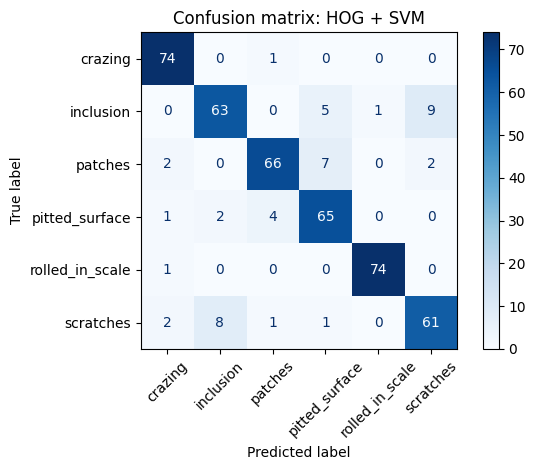

In [12]:
best = res_df.sort_values('f1', ascending=False).iloc[0]
cell, orient = int(best['cell']), int(best['orient'])
print(f'Best HOG setting by macro F1 (SVM or RF): cell={cell}, orient={orient}')

X = features(cell, orient)
svm = make_models()['HOG + SVM'].fit(X[idx_tr], y[idx_tr])
rf = make_models()['HOG + RandomForest'].fit(X[idx_tr], y[idx_tr])

for name, clf in [('HOG + SVM', svm), ('HOG + RandomForest', rf)]:
    print('=====', name, '=====')
    print(classification_report(y[idx_te], clf.predict(X[idx_te]), zero_division=0))

cm = confusion_matrix(y[idx_te], svm.predict(X[idx_te]), labels=svm.classes_)
ConfusionMatrixDisplay(cm, display_labels=svm.classes_).plot(xticks_rotation=45, cmap='Blues')
plt.title('Confusion matrix: HOG + SVM'); plt.tight_layout(); plt.show()

## 10. Robustness analysis (Task 12)
The model is trained on clean images. Each perturbation is applied only to the held-out test images.

In [13]:
rng = np.random.default_rng(0)

def perturb(img, kind):
    if kind == 'brightness':
        return np.clip(img.astype(np.float32) * 1.4 + 30, 0, 255).astype(np.uint8)
    if kind == 'noise':
        return np.clip(img + rng.normal(0, 15, img.shape), 0, 255).astype(np.uint8)
    if kind == 'rotation':
        h, w = img.shape
        M = cv2.getRotationMatrix2D((w / 2, h / 2), 15, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    if kind == 'blur':
        return cv2.GaussianBlur(img, (5, 5), 1.5)
    raise ValueError(kind)

base = metrics(y[idx_te], svm.predict(X[idx_te]))
rows = [{'condition': 'clean', **base}]
for kind in ['brightness', 'noise', 'rotation', 'blur']:
    Xp = np.array([hog_feat(perturb(images[i], kind), cell, orient) for i in idx_te], dtype=np.float32)
    rows.append({'condition': kind, **metrics(y[idx_te], svm.predict(Xp))})

rob = pd.DataFrame(rows)
rob['delta_acc'] = rob['accuracy'] - base['accuracy']
rob['delta_f1'] = rob['f1'] - base['f1']
rob.round(3)

,condition,accuracy,precision,recall,f1,delta_acc,delta_f1
0,clean,0.896,0.895,0.896,0.895,0.000,0.000
1,brightness,0.176,0.238,0.180,0.074,-0.720,-0.821
2,noise,0.453,0.517,0.456,0.368,-0.442,-0.527
3,rotation,0.789,0.805,0.791,0.785,-0.107,-0.110
4,blur,0.227,0.360,0.230,0.163,-0.669,-0.732


## 11. Quality-control decision module (Task 13)

In [14]:
def inspect_product(image_path, model=svm, cell=cell, orient=orient):
    img = preprocess(image_path)
    feat = hog_feat(img, cell, orient).reshape(1, -1).astype(np.float32)
    probs = model.predict_proba(feat)[0]
    k = int(np.argmax(probs))
    label, conf = model.classes_[k], probs[k] * 100

    if label == 'normal':
        verdict, action = 'NON-DEFECTIVE', 'ACCEPT PRODUCT'
    else:
        verdict, action = 'DEFECTIVE', 'REJECT PRODUCT'

    print('PRODUCT INSPECTION RESULT')
    print(f'Prediction: {verdict} ({label})')
    print(f'Confidence: {conf:.0f}%')
    print(f'Action: {action}')

inspect_product(df.path.iloc[0])

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE (pitted_surface)
Confidence: 99%
Action: REJECT PRODUCT


## 12. Notes for the report

- **Dataset:** NEU-DET, six defect classes, 200×200 grayscale. It has no defect-free class, so this notebook runs multi-class classification (allowed for advanced work). To run the binary Normal/Defective task, add defect-free images in a `normal` folder.
- **Split:** Stratified 75/25 split with a fixed seed. For more reliable numbers, use 5-fold cross-validation.
- **Sweep:** Put the table from Section 8 into the report. Cell size 4 produces the largest feature vectors and is the slowest.
- **Limitations:** Single split, a single robustness angle (15°), small image size (128 px) that can hide fine scratches, and no defect-free class.
- **Bonus:** Replace `DATA_ROOT` images with frames from `cv2.VideoCapture(0)`, run `preprocess` on each frame, and display PASS or DEFECTIVE.